# 🛍️ RetailSight: Retail Sales Analysis

## 📌 Objective
The goal of this project is to analyze retail sales data to identify trends, top-performing categories, and business insights that support decision-making.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


The dataset contains retail sales information including order date, category, region, and sales values.

In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Month'] = df['Order Date'].dt.to_period('M')

Converted date column into datetime format and extracted month for time-based analysis.

In [5]:
total_sales = df['Sales'].sum()
total_orders = df.shape[0]
avg_order_value = df['Sales'].mean()

total_sales, total_orders, avg_order_value

(np.float64(2261536.7827000003), 9800, np.float64(230.7690594591837))

###  KPI Insights
- Total sales show overall performance
- Average order value indicates customer spending

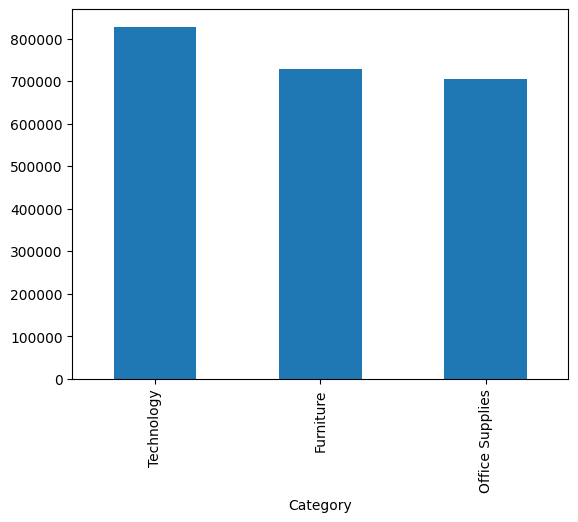

In [6]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
category_sales.plot(kind='bar')
plt.show()

Technology category shows the highest contribution to total sales.

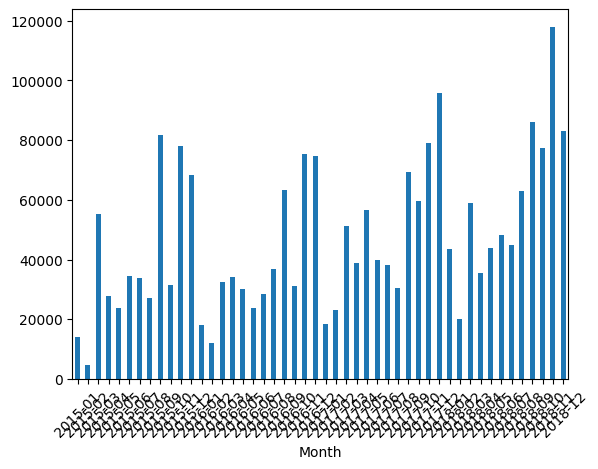

In [7]:
monthly_sales = df.groupby('Month')['Sales'].sum()
monthly_sales.plot(kind='bar')
plt.xticks(rotation=45)
plt.show()

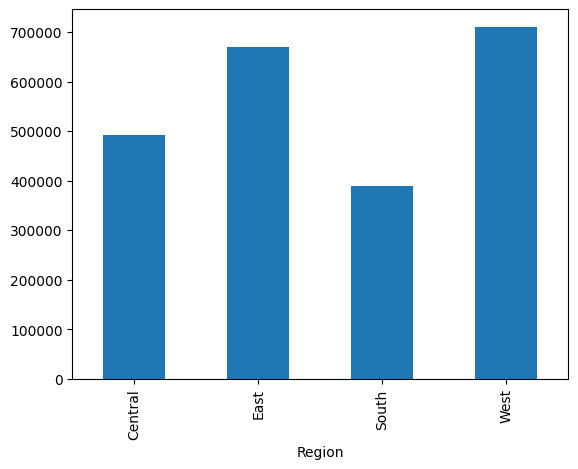

In [8]:
region_sales = df.groupby('Region')['Sales'].sum()
region_sales.plot(kind='bar')
plt.show()

Certain regions dominate sales performance, indicating regional demand differences.

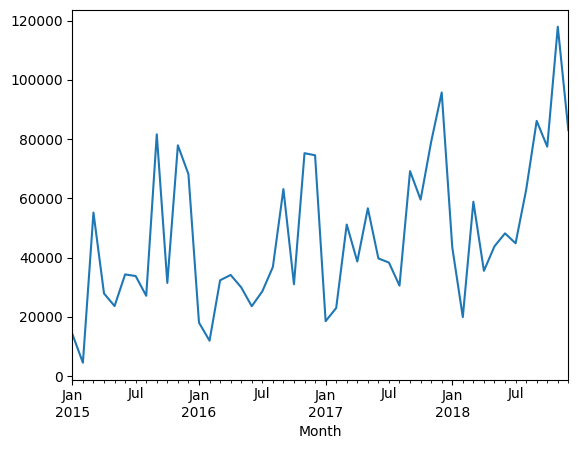

In [9]:
monthly_sales = df.groupby('Month')['Sales'].sum()
monthly_sales.plot()
plt.show()

Sales show trends over time, indicating possible seasonality.

In [10]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

A small number of products contribute significantly to overall revenue.

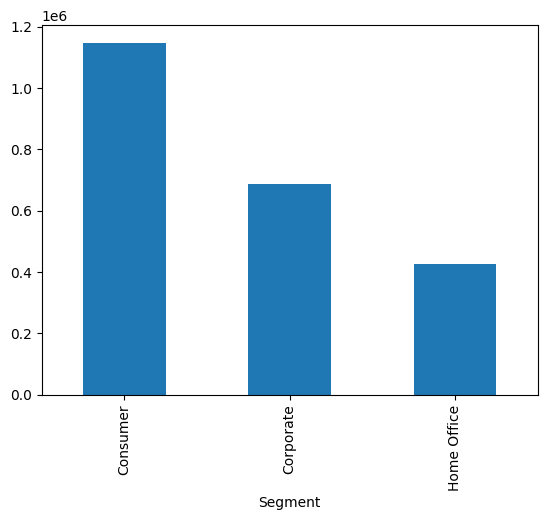

In [11]:
segment_sales = df.groupby('Segment')['Sales'].sum()
segment_sales.plot(kind='bar')
plt.show()

In [12]:
from sklearn.linear_model import LinearRegression

df['Days'] = (df['Order Date'] - df['Order Date'].min()).dt.days

X = df[['Days']]
y = df['Sales']

model = LinearRegression()
model.fit(X, y)

prediction = model.predict([[df['Days'].max() + 7]])
prediction

c:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([221.30003012])

A simple Linear Regression model is used to predict future sales based on historical trends.

## ✅ Conclusion

- Technology category is the top performer  
- Sales vary across regions  
- Time-based trends indicate seasonal patterns  
- Machine learning model provides basic sales forecasting  

This analysis helps businesses make data-driven decisions.